## ml_v9 : Binary 구간 25/75 적용 (레이블 품질 개선)
* ml_v8 기반
* Binary threshold: 30/70 → **25/75** (극단값 더 좁혀서 레이블 노이즈 감소)
* 구간 비교 실험 결과: 25/25 untuned AUC 0.7335 vs 30/30 0.7141 (+0.019)
* 선케어 피처 강화 (is_zinc_oxide, is_titanium_dioxide, chemical_filter_only, spf_bin)
* 용량 구간화 (vol_small/mid/large) 추가
* gt_vitamin_c, gt_retinol 제거 / top5_active_count 제거
* 선케어 sample_weight 4배
* --> 목표 Test AUC 0.77+

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict, RandomizedSearchCV, GridSearchCV, train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from lightgbm import LGBMClassifier
from scipy.stats import randint, uniform
import re, warnings, pickle, os
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

DATA_PATH = r"C:\workspace\finalproject\data\ml_AmazonSephoraUlta.csv"
df_all = pd.read_csv(DATA_PATH, encoding='utf-8-sig', low_memory=False)
df_all['카테고리(중)'] = df_all['카테고리(중)'].str.lower().str.strip()

print(f"전체: {len(df_all)}개")
print(f"플랫폼별:\n{df_all['store_id'].str.split('_').str[0].value_counts().to_string()}")
print(f"\nsentiment_score 있음: {df_all['sentiment_score'].notna().sum()}개")
print(f"리뷰수 있음: {df_all['리뷰수'].notna().sum()}개")
print(f"\ntarget_category 분포:\n{df_all['target_category'].value_counts().to_string()}")
print(f"\n카테고리(중) 분포:\n{df_all['카테고리(중)'].value_counts().to_string()}")

c:\Users\asiae\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\asiae\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


전체: 5964개
플랫폼별:
store_id
amazon     2560
sephora    1802
ulta       1602

sentiment_score 있음: 4411개
리뷰수 있음: 5929개

target_category 분포:
target_category
skincare     3963
cleansing    1037
suncare       551
masks         413

카테고리(중) 분포:
카테고리(중)
cream                    1830
cleansing foam/gel        679
essence/serum/ampoule     554
moisturizers              539
treatments                459
sun cream                 410
cleansers                 354
eye care                  273
wash-off pack             237
masks                     161
sunscreen                 105
skin/toner                 90
mist/fixer                 54
lip & eye remover          50
cleansing oil              42
sun stick                  36
cleansing balm             28
sheet mask                 21
cleansing tissue/pad       16
patch                      15
lotion                     11


In [2]:
# ── Y값
df_labeled = df_all[df_all['sentiment_score'].notna() & df_all['리뷰수'].notna()].copy()
df_labeled['y1'] = df_labeled['sentiment_score']
df_labeled['y2'] = np.log1p(df_labeled['리뷰수']) / np.log1p(df_labeled['리뷰수'].max())

scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(df_labeled[['y1', 'y2']])
pca = PCA(n_components=1)
y_pca = pca.fit_transform(y_scaled)
print(f"PCA 분산 설명력: {pca.explained_variance_ratio_[0]:.3f}")
print(f"PC1 로딩: y1(감성)={pca.components_[0,0]:.3f}  y2(리뷰수)={pca.components_[0,1]:.3f}")

qt = QuantileTransformer(output_distribution='uniform', random_state=42)
df_labeled['y_pca'] = qt.fit_transform(y_pca)

# [v9] threshold 25/75 (레이블 노이즈 감소)
th_lo, th_hi = 0.25, 0.75
mask  = (df_labeled['y_pca'] <= th_lo) | (df_labeled['y_pca'] >= th_hi)
df_y  = df_labeled[mask].copy()
df_y['target'] = (df_y['y_pca'] >= th_hi).astype(int)

print(f"\n전체 라벨 데이터: {len(df_labeled)}개")
print(f"학습 데이터 (25/75): {len(df_y)}개  (긍정={df_y['target'].sum()}, 부정={len(df_y)-df_y['target'].sum()})")

PCA 분산 설명력: 0.512
PC1 로딩: y1(감성)=0.707  y2(리뷰수)=0.707

전체 라벨 데이터: 4411개
학습 데이터 (25/75): 2206개  (긍정=1104, 부정=1102)


In [3]:
# ── 피처 생성 (df_labeled 기준 → 구간 실험에서 재활용 가능)
ing_cols = [c for c in df_labeled.columns if c.startswith('성분_')]
df_labeled['ingredient_text'] = df_labeled[ing_cols].fillna('').agg(' '.join, axis=1).str.strip()
ing_lower = df_labeled['ingredient_text'].str.lower()

def extract_ml(s):
    if pd.isna(s): return np.nan
    m = re.search(r'([\d.]+)\s*ml', str(s), re.IGNORECASE)
    if m: return float(m.group(1))
    m = re.search(r'([\d.]+)\s*oz', str(s), re.IGNORECASE)
    if m: return float(m.group(1)) * 29.5735
    return np.nan
df_labeled['volume_ml'] = df_labeled['용량'].apply(extract_ml)

vol_d = pd.get_dummies(
    pd.cut(df_labeled['volume_ml'], bins=[0, 50, 150, 9999], labels=['small', 'mid', 'large']),
    prefix='vol'
).astype(int)
df_labeled = pd.concat([df_labeled, vol_d], axis=1)

price_d = pd.get_dummies(
    pd.cut(df_labeled['공급가(USD)'], bins=[0,30,71,9999], labels=['low','mid','high']),
    prefix='price'
).astype(int)
df_labeled = pd.concat([df_labeled, price_d], axis=1)

cat_d = pd.get_dummies(df_labeled['target_category'], prefix='cat').astype(int)
df_labeled = pd.concat([df_labeled, cat_d], axis=1)

mid_counts = df_labeled['카테고리(중)'].value_counts()
valid_mid  = mid_counts[mid_counts >= 50].index
df_labeled['cat_mid'] = df_labeled['카테고리(중)'].where(df_labeled['카테고리(중)'].isin(valid_mid), other='기타')
mid_d = pd.get_dummies(df_labeled['cat_mid'], prefix='mid').astype(int)
df_labeled = pd.concat([df_labeled, mid_d], axis=1)

kbeauty_map = {
    'k_galactomyces': 'galactomyces', 'k_bifida':      'bifida',
    'k_centella':     'centella',     'k_ginseng':     'ginseng',
    'k_snail':        'snail',        'k_beta_glucan': 'beta-glucan',
    'k_bakuchiol':    'bakuchiol',    'k_pdrn':        'polydeoxyribonucleotide|pdrn',
    'k_propolis':     'propolis',
}
for feat, kw in kbeauty_map.items():
    df_labeled[feat] = ing_lower.str.contains(kw, regex=True).astype(int)
k_cols = list(kbeauty_map.keys())
df_labeled['k_beauty_ratio'] = df_labeled[k_cols].sum(axis=1) / len(k_cols)

gt_map = {
    'gt_tocopherol':        'tocopherol',
    'gt_tocopheryl_acetate':'tocopheryl acetate',
    'gt_sodium_hyaluronate':'sodium hyaluronate',
    'gt_panthenol':         'panthenol',
    'gt_caprylic':          'caprylic',
    'gt_pdrn':              'polydeoxyribonucleotide',
    'gt_exosome':           'exosome',
    'gt_nad':               'nicotinamide adenine',
    'gt_bakuchiol':         'bakuchiol',
    'gt_azelaic_acid':      'azelaic acid',
    'gt_tranexamic_acid':   'tranexamic acid',
    'gt_ectoin':            'ectoin',
    'gt_peptide':           'peptide',
    'gt_squalane':          'squalane',
    'gt_caffeine':          'caffeine',
}
for feat, kw in gt_map.items():
    df_labeled[feat] = ing_lower.str.contains(kw, regex=True).astype(int)
gt_cols = list(gt_map.keys())
df_labeled['us_trend_ratio'] = df_labeled[gt_cols].sum(axis=1) / len(gt_cols)

# 선케어 전용 피처
df_labeled['is_zinc_oxide']       = ing_lower.str.contains('zinc oxide',       regex=False).astype(int)
df_labeled['is_titanium_dioxide'] = ing_lower.str.contains('titanium dioxide', regex=False).astype(int)
df_labeled['chemical_filter_only'] = (
    (df_labeled['is_zinc_oxide'] == 0) & (df_labeled['is_titanium_dioxide'] == 0)
    & (df_labeled['cat_suncare'] == 1)
).astype(int)

spf = df_labeled['SPF_Index'].fillna(0)
df_labeled['spf_bin_low']  = ((spf > 0)  & (spf <= 30)).astype(int)
df_labeled['spf_bin_mid']  = ((spf > 30) & (spf <= 50)).astype(int)
df_labeled['spf_bin_high'] = (spf > 50).astype(int)

# ── [v9] 25/75 threshold df_y 재파생
th_lo, th_hi = 0.25, 0.75
mask  = (df_labeled['y_pca'] <= th_lo) | (df_labeled['y_pca'] >= th_hi)
df_y  = df_labeled[mask].copy()
df_y['target'] = (df_y['y_pca'] >= th_hi).astype(int)

print("피처 생성 완료 (df_labeled 기준, threshold 25/75)")
print(f"학습 데이터: {len(df_y)}개  (긍정={df_y['target'].sum()}, 부정={len(df_y)-df_y['target'].sum()})")
print(f"GT 성분 수: {len(gt_cols)}개")
print(f"\n선케어 전용 피처 커버리지:")
for c in ['is_zinc_oxide','is_titanium_dioxide','chemical_filter_only',
          'spf_bin_low','spf_bin_mid','spf_bin_high']:
    print(f"  {c}: {df_labeled[c].mean()*100:.1f}%")

피처 생성 완료 (df_labeled 기준, threshold 25/75)
학습 데이터: 2206개  (긍정=1104, 부정=1102)
GT 성분 수: 15개

선케어 전용 피처 커버리지:
  is_zinc_oxide: 1.8%
  is_titanium_dioxide: 7.8%
  chemical_filter_only: 1.5%
  spf_bin_low: 3.0%
  spf_bin_mid: 2.1%
  spf_bin_high: 0.1%


유의미한 피처 (p<0.05): 22개 / 58개

                       feature    corr  p_value sig
                     volume_ml  0.1667   0.0000   ★
us_trend_ingredient_above_1pct  0.1583   0.0000   ★
                     price_mid  0.1535   0.0000   ★
                mid_treatments  0.1358   0.0000   ★
                 mid_cleansers  0.0974   0.0000   ★
              mid_moisturizers  0.0933   0.0000   ★
         gt_tocopheryl_acetate  0.0869   0.0000   ★
                 cat_cleansing  0.0820   0.0001   ★
amino_acid_surfactant_position  0.0700   0.0010   ★
                us_trend_ratio  0.0452   0.0339   ★
         gt_sodium_hyaluronate  0.0421   0.0478   ★
             ceramide_position  0.0322   0.1305    
         top30pct_active_count  0.0304   0.1541    
        mid_cleansing foam/gel  0.0277   0.1934    
      hyaluronic_acid_position  0.0258   0.2254    
                      k_bifida  0.0256   0.2284    
          niacinamide_position  0.0239   0.2613    
                   gt_caffeine  0.0

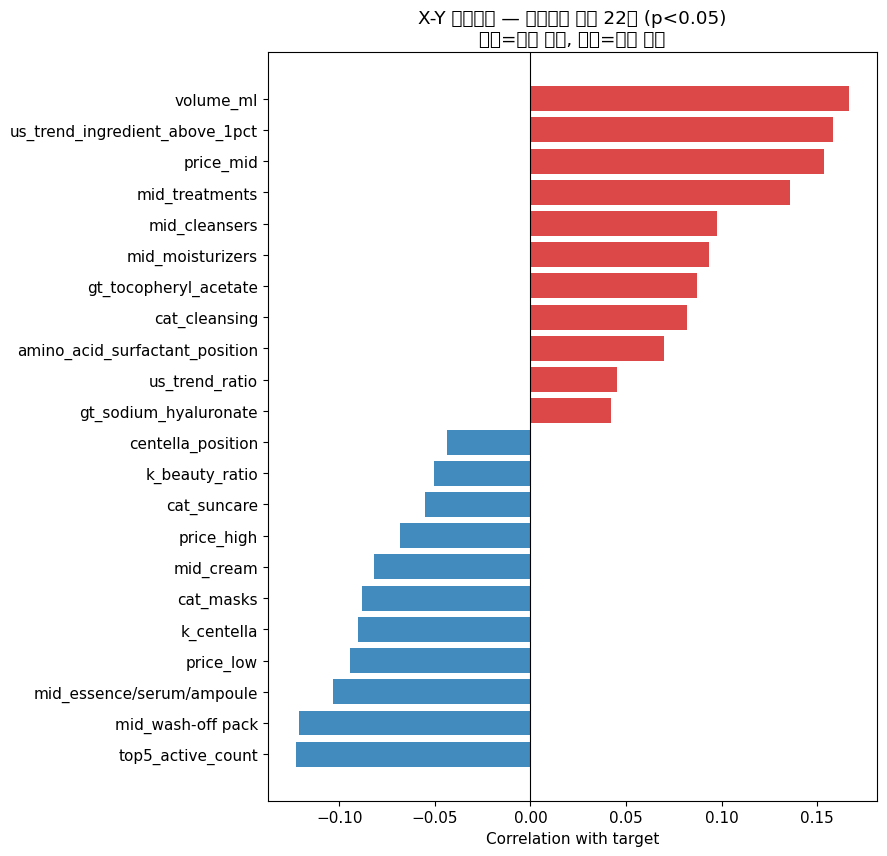

In [4]:
# ── X-Y 상관분석 (전체 데이터 기준, 피처 구성 후 실행)
from scipy.stats import pointbiserialr, chi2_contingency

# feat_cols 구성 (피처 구성 셀보다 먼저 실행 시 아래 임시 구성)
precomp_pos_cols_tmp = [
    'niacinamide_position', 'ceramide_position', 'hyaluronic_acid_position',
    'zinc_oxide_position', 'centella_position', 'pdrn_position',
    'amino_acid_surfactant_position', 'top5_active_count', 'top30pct_active_count',
    'us_trend_ingredient_position', 'us_trend_ingredient_above_1pct',
]
mid_feat_cols_tmp = [c for c in df_y.columns if c.startswith('mid_')]
feat_cols_eda = (
    ['price_low','price_mid','price_high','volume_ml','SPF_Index']
    + [c for c in df_y.columns if c.startswith('cat_') and not c.startswith('cat_mid')]
    + mid_feat_cols_tmp + k_cols + ['k_beauty_ratio']
    + gt_cols + ['us_trend_ratio']
    + [c for c in precomp_pos_cols_tmp if c in df_y.columns]
)
feat_cols_eda = [c for c in feat_cols_eda if c in df_y.columns]

results = []
for col in feat_cols_eda:
    x = df_y[col].fillna(0)
    y_t = df_y['target']
    if x.nunique() <= 2:
        ct = pd.crosstab(x, y_t)
        if ct.shape == (2, 2):
            chi2, p, _, _ = chi2_contingency(ct)
            sign = np.sign(
                ct.iloc[1,1]/(ct.iloc[1,0]+1e-9) - ct.iloc[0,1]/(ct.iloc[0,0]+1e-9)
            )
            corr = np.sqrt(chi2 / len(x)) * sign
        else:
            corr, p = 0.0, 1.0
    else:
        corr, p = pointbiserialr(x, y_t)
    results.append({'feature': col, 'corr': round(corr, 4), 'p_value': round(p, 4),
                    'sig': '★' if p < 0.05 else ''})

corr_df = pd.DataFrame(results).sort_values('corr', ascending=False).reset_index(drop=True)
sig_count = (corr_df['p_value'] < 0.05).sum()
print(f"유의미한 피처 (p<0.05): {sig_count}개 / {len(feat_cols_eda)}개\n")
print(corr_df[['feature','corr','p_value','sig']].to_string(index=False))

# 시각화 (유의미한 피처만)
sig_df = corr_df[corr_df['p_value'] < 0.05].sort_values('corr')
fig, ax = plt.subplots(figsize=(9, len(sig_df)*0.35 + 1))
colors = ['#d62728' if c > 0 else '#1f77b4' for c in sig_df['corr']]
ax.barh(sig_df['feature'], sig_df['corr'], color=colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlation with target')
ax.set_title(f'X-Y 상관분석 — 유의미한 피처 {len(sig_df)}개 (p<0.05)\n빨강=긍정 상관, 파랑=부정 상관')
plt.tight_layout()
plt.show()

In [5]:
# ── 피처 구성 + Train/Test 분리 (80/20 무작위) ── 일반 모델
# [수정] top5_active_count 제거 / 선케어 피처 + 용량 구간 추가
precomp_pos_cols = [
    'niacinamide_position',
    'ceramide_position',
    'hyaluronic_acid_position',
    'zinc_oxide_position',
    'centella_position',
    'pdrn_position',
    'amino_acid_surfactant_position',
    # top5_active_count 제거 (음의 상관 -0.116, 노이즈)
    'top30pct_active_count',
    'us_trend_ingredient_position', 'us_trend_ingredient_above_1pct',
]
precomp_pos_cols = [c for c in precomp_pos_cols if c in df_y.columns]
mid_feat_cols    = [c for c in df_y.columns if c.startswith('mid_')]

feat_cols = (
    ['price_low', 'price_mid', 'price_high']
    + ['volume_ml', 'vol_small', 'vol_mid', 'vol_large']
    + ['SPF_Index', 'spf_bin_low', 'spf_bin_mid', 'spf_bin_high']
    + ['is_zinc_oxide', 'is_titanium_dioxide', 'chemical_filter_only']
    + [c for c in df_y.columns if c.startswith('cat_') and not c.startswith('cat_mid')]
    + mid_feat_cols
    + k_cols + ['k_beauty_ratio']
    + gt_cols + ['us_trend_ratio']
    + precomp_pos_cols
)
feat_cols = [c for c in feat_cols if c in df_y.columns]

X_all = df_y[feat_cols].fillna(0).astype(float).values
y_all = df_y['target'].values

# 인덱스 기반 분리 후 cat 별도 추출
indices = np.arange(len(df_y))
train_idx, test_idx = train_test_split(
    indices, test_size=0.2, stratify=y_all, random_state=42
)
X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]
cat_train = df_y['target_category'].iloc[train_idx].to_numpy()
cat_test  = df_y['target_category'].iloc[test_idx].to_numpy()

print(f"[일반 모델] 피처 수: {len(feat_cols)}개")
print(f"Train: {len(y_train)}개 | Test: {len(y_test)}개")
print(f"Train 중 선케어: {(cat_train == 'suncare').sum()}개 "
      f"| Test 중 선케어: {(cat_test == 'suncare').sum()}개")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_base = cross_validate(LGBMClassifier(random_state=42, verbose=-1),
                          X_train, y_train, cv=skf, scoring=['roc_auc'])['test_roc_auc'].mean()
print(f"\n베이스라인 Train CV AUC: {auc_base:.4f}")

[일반 모델] 피처 수: 66개
Train: 1764개 | Test: 442개
Train 중 선케어: 42개 | Test 중 선케어: 14개

베이스라인 Train CV AUC: 0.7360


In [6]:
# ── 일반 모델: Importance Pruning + RandomizedSearch + GridSearch
# 선케어 샘플 4배 가중치 (67개 → 과소대표 보정)
sw_train = np.where(cat_train == 'suncare', 4.0, 1.0)

low_cov = [c for c in gt_cols if df_y[c].mean() < 0.05]
feat_cols_pruned = [c for c in feat_cols if c not in low_cov]

feat_idx = [feat_cols.index(c) for c in feat_cols_pruned]
lgbm_tmp = LGBMClassifier(random_state=42, verbose=-1)
lgbm_tmp.fit(X_train[:, feat_idx], y_train, sample_weight=sw_train)
imp = pd.Series(lgbm_tmp.feature_importances_, index=feat_cols_pruned)
zero_imp = imp[imp == 0].index.tolist()
feat_cols_pruned = [c for c in feat_cols_pruned if c not in zero_imp]
print(f"커버리지 5% 미만 제거: {len(low_cov)}개 | Importance=0 제거: {len(zero_imp)}개")
print(f"최종 피처 수: {len(feat_cols_pruned)}개")

final_idx = [feat_cols.index(c) for c in feat_cols_pruned]
X_tr = X_train[:, final_idx]
X_te = X_test[:, final_idx]

# RandomizedSearch
param_dist = {
    'n_estimators':      randint(100, 500),
    'max_depth':         randint(4, 12),
    'num_leaves':        randint(20, 100),
    'learning_rate':     uniform(0.01, 0.09),
    'min_child_samples': randint(10, 50),
    'subsample':         uniform(0.6, 0.4),
    'colsample_bytree':  uniform(0.6, 0.4),
    'reg_alpha':         uniform(0, 0.1),
    'reg_lambda':        uniform(0, 0.1),
}
rs = RandomizedSearchCV(LGBMClassifier(random_state=42, verbose=-1),
                        param_distributions=param_dist, n_iter=100,
                        scoring='roc_auc', cv=skf, random_state=42, n_jobs=-1)
rs.fit(X_tr, y_train, sample_weight=sw_train)
print(f"\nRandomizedSearch Train CV AUC: {rs.best_score_:.4f}")

# GridSearch
bp = rs.best_params_
param_grid = {
    'n_estimators':      [max(100, bp['n_estimators']-50), bp['n_estimators'], bp['n_estimators']+50],
    'max_depth':         [max(3, bp['max_depth']-1), bp['max_depth'], bp['max_depth']+1],
    'num_leaves':        [max(10, bp['num_leaves']-10), bp['num_leaves'], bp['num_leaves']+10],
    'learning_rate':     [round(bp['learning_rate']*0.8, 4), round(bp['learning_rate'], 4), round(bp['learning_rate']*1.2, 4)],
    'min_child_samples': [max(5, bp['min_child_samples']-5), bp['min_child_samples'], bp['min_child_samples']+5],
}
gs = GridSearchCV(
    LGBMClassifier(colsample_bytree=bp['colsample_bytree'], subsample=bp['subsample'],
                   reg_alpha=bp['reg_alpha'], reg_lambda=bp['reg_lambda'],
                   random_state=42, verbose=-1),
    param_grid=param_grid, scoring='roc_auc', cv=skf, n_jobs=-1
)
gs.fit(X_tr, y_train, sample_weight=sw_train)
print(f"GridSearch Train CV AUC: {gs.best_score_:.4f}")

# Test 평가
general_model = gs.best_estimator_
general_model.fit(X_tr, y_train, sample_weight=sw_train)
test_auc_general = roc_auc_score(y_test, general_model.predict_proba(X_te)[:, 1])
print(f"\n[일반 모델] Train CV AUC: {gs.best_score_:.4f}  |  Test AUC: {test_auc_general:.4f}")
print(f"과적합 갭: {gs.best_score_ - test_auc_general:+.4f}")
print(classification_report(y_test, general_model.predict(X_te)))

# 선케어 서브셋 AUC 별도 확인
sc_mask = (cat_test == 'suncare')
if sc_mask.sum() >= 10:
    sc_auc = roc_auc_score(y_test[sc_mask], general_model.predict_proba(X_te[sc_mask])[:, 1])
    print(f"\n[선케어 서브셋] Test AUC: {sc_auc:.4f}  (n={sc_mask.sum()})")
else:
    print(f"\n[선케어 서브셋] 샘플 부족 (n={sc_mask.sum()})")

feat_cols_general = feat_cols_pruned

커버리지 5% 미만 제거: 10개 | Importance=0 제거: 8개
최종 피처 수: 48개

RandomizedSearch Train CV AUC: 0.7394
GridSearch Train CV AUC: 0.7400

[일반 모델] Train CV AUC: 0.7400  |  Test AUC: 0.7158
과적합 갭: +0.0242
              precision    recall  f1-score   support

           0       0.64      0.67      0.65       221
           1       0.65      0.62      0.63       221

    accuracy                           0.64       442
   macro avg       0.65      0.64      0.64       442
weighted avg       0.65      0.64      0.64       442


[선케어 서브셋] Test AUC: 0.8788  (n=14)


In [7]:
# ── Binary 구간 비교 실험 (25/25, 30/30, 35/35, 40/40)
from sklearn.model_selection import cross_val_score

precomp_pos_exp = [c for c in [
    'niacinamide_position', 'ceramide_position', 'hyaluronic_acid_position',
    'zinc_oxide_position', 'centella_position', 'pdrn_position',
    'amino_acid_surfactant_position', 'top30pct_active_count',
    'us_trend_ingredient_position', 'us_trend_ingredient_above_1pct',
] if c in df_labeled.columns]

mid_feat_exp = [c for c in df_labeled.columns if c.startswith('mid_')]
feat_cols_exp = (
    ['price_low', 'price_mid', 'price_high']
    + ['volume_ml', 'vol_small', 'vol_mid', 'vol_large']
    + ['SPF_Index', 'spf_bin_low', 'spf_bin_mid', 'spf_bin_high']
    + ['is_zinc_oxide', 'is_titanium_dioxide', 'chemical_filter_only']
    + [c for c in df_labeled.columns if c.startswith('cat_') and not c.startswith('cat_mid')]
    + mid_feat_exp + k_cols + ['k_beauty_ratio']
    + gt_cols + ['us_trend_ratio']
    + precomp_pos_exp
)
feat_cols_exp = [c for c in feat_cols_exp if c in df_labeled.columns]

print(f"{'구간':>8} | {'샘플수':>6} | {'선케어':>6} | {'CV AUC':>8}")
print("-" * 42)

skf5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for pct in [25, 30, 35, 40]:
    t_lo, t_hi = pct / 100, 1 - pct / 100
    m = (df_labeled['y_pca'] <= t_lo) | (df_labeled['y_pca'] >= t_hi)
    df_exp = df_labeled[m].copy()
    df_exp['target'] = (df_exp['y_pca'] >= t_hi).astype(int)

    X_exp = df_exp[feat_cols_exp].fillna(0).astype(float).values
    y_exp = df_exp['target'].values
    sc_n  = (df_exp['target_category'] == 'suncare').sum()

    auc = cross_val_score(
        LGBMClassifier(n_estimators=200, random_state=42, verbose=-1),
        X_exp, y_exp, cv=skf5, scoring='roc_auc'
    ).mean()
    marker = ' ← v9 채택' if pct == 25 else (' ← v8' if pct == 30 else '')
    print(f"  {pct}/{pct}   | {len(df_exp):>6} | {sc_n:>6} | {auc:.4f}{marker}")

      구간 |    샘플수 |    선케어 |   CV AUC
------------------------------------------
  25/25   |   2206 |     56 | 0.7335 ← v9 채택
  30/30   |   2648 |     67 | 0.7141 ← v8
  35/35   |   3088 |     79 | 0.7034
  40/40   |   3528 |     90 | 0.6872
